In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\maham\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
columns = ["user", "activity", "timestamp", "x", "y", "z"]

data = pd.read_csv(
    "WISDM_ar_v1.1_raw.txt",
    sep=",",
    header=None,
    names=columns,
    engine="python",
    on_bad_lines="skip"  
)

In [3]:
# Remove trailing semicolon from z column
data["z"] = data["z"].astype(str).str.replace(";", "", regex=False)

# Convert sensor values to numeric
for col in ["x", "y", "z"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Drop rows with invalid values
data.dropna(inplace=True)

print(data.head())
print("Rows after cleaning:", len(data))

   user activity       timestamp         x          y         z
0    33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1    33  Jogging  49106062271000  5.012288  11.264028  0.953424
2    33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3    33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4    33  Jogging  49106332290000 -1.184970  12.108489  7.205164
Rows after cleaning: 1086465


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["label"] = le.fit_transform(data["activity"])

print(data[["activity", "label"]].head())

  activity  label
0  Jogging      1
1  Jogging      1
2  Jogging      1
3  Jogging      1
4  Jogging      1


In [5]:
SEQUENCE_LENGTH = 50

X, y = [], []

features = data[["x", "y", "z"]].values
labels = data["label"].values

for i in range(len(features) - SEQUENCE_LENGTH):
    X.append(features[i:i + SEQUENCE_LENGTH])
    y.append(labels[i + SEQUENCE_LENGTH])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1086415, 50, 3)
y shape: (1086415,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["label"] = le.fit_transform(data["activity"])

In [8]:
SEQUENCE_LENGTH = 50

X, y = [], []

features = data[["x", "y", "z"]].values
labels = data["label"].values

for i in range(len(features) - SEQUENCE_LENGTH):
    X.append(features[i:i + SEQUENCE_LENGTH])
    y.append(labels[i + SEQUENCE_LENGTH])

X = np.array(X)
y = np.array(y)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Training RNN Model...


C:\Users\maham\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 79s 7ms/step - accuracy: 0.8090 - loss: 0.5499 - val_accuracy: 0.8758 - val_loss: 0.3476
Epoch 2/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 83s 7ms/step - accuracy: 0.8476 - loss: 0.4390 - val_accuracy: 0.8845 - val_loss: 0.3302
Epoch 3/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 78s 7ms/step - accuracy: 0.7714 - loss: 0.6599 - val_accuracy: 0.8429 - val_loss: 0.4338
Epoch 4/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 89s 8ms/step - accuracy: 0.8235 - loss: 0.5075 - val_accuracy: 0.8246 - val_loss: 0.4833
Epoch 5/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 87s 8ms/step - accuracy: 0.7799 - loss: 0.6212 - val_accuracy: 0.7786 - val_loss: 0.6102
Epoch 6/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 89s 8ms/step - accuracy: 0.7911 - loss: 0.5952 - val_accuracy: 0.7535 - val_loss: 0.7157
Epoch 7/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 88s 8ms/step - accuracy: 0.7625 - loss: 0.6833 - val_accuracy: 0.7250 - val_loss: 0.9553
6791/6791 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step
RNN Accuracy: 0.8857
RNN 

C:\Users\maham\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 245s 22ms/step - accuracy: 0.9506 - loss: 0.1487 - val_accuracy: 0.9821 - val_loss: 0.0601
Epoch 2/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 253s 23ms/step - accuracy: 0.9849 - loss: 0.0498 - val_accuracy: 0.9865 - val_loss: 0.0433
Epoch 3/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 249s 23ms/step - accuracy: 0.9900 - loss: 0.0335 - val_accuracy: 0.9914 - val_loss: 0.0292
Epoch 4/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 292s 27ms/step - accuracy: 0.9924 - loss: 0.0259 - val_accuracy: 0.9931 - val_loss: 0.0239
Epoch 5/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 306s 28ms/step - accuracy: 0.9937 - loss: 0.0214 - val_accuracy: 0.9922 - val_loss: 0.0262
Epoch 6/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 366s 34ms/step - accuracy: 0.9945 - loss: 0.0187 - val_accuracy: 0.9950 - val_loss: 0.0169
Epoch 7/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 319s 29ms/step - accuracy: 0.9952 - loss: 0.0165 - val_accuracy: 0.9951 - val_loss: 0.0167
Epoch 8/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 313s 28ms/s

C:\Users\maham\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 219s 20ms/step - accuracy: 0.9532 - loss: 0.1436 - val_accuracy: 0.9819 - val_loss: 0.0628
Epoch 2/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 214s 20ms/step - accuracy: 0.9850 - loss: 0.0507 - val_accuracy: 0.9855 - val_loss: 0.0477
Epoch 3/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 221s 20ms/step - accuracy: 0.9890 - loss: 0.0375 - val_accuracy: 0.9876 - val_loss: 0.0440
Epoch 4/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 212s 19ms/step - accuracy: 0.9910 - loss: 0.0305 - val_accuracy: 0.9921 - val_loss: 0.0274
Epoch 5/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 214s 20ms/step - accuracy: 0.9918 - loss: 0.0274 - val_accuracy: 0.9916 - val_loss: 0.0291
Epoch 6/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 207s 19ms/step - accuracy: 0.9928 - loss: 0.0241 - val_accuracy: 0.9907 - val_loss: 0.0318
Epoch 7/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 206s 19ms/step - accuracy: 0.9930 - loss: 0.0235 - val_accuracy: 0.9928 - val_loss: 0.0245
Epoch 8/30
10865/10865 ━━━━━━━━━━━━━━━━━━━━ 204s 19ms/s

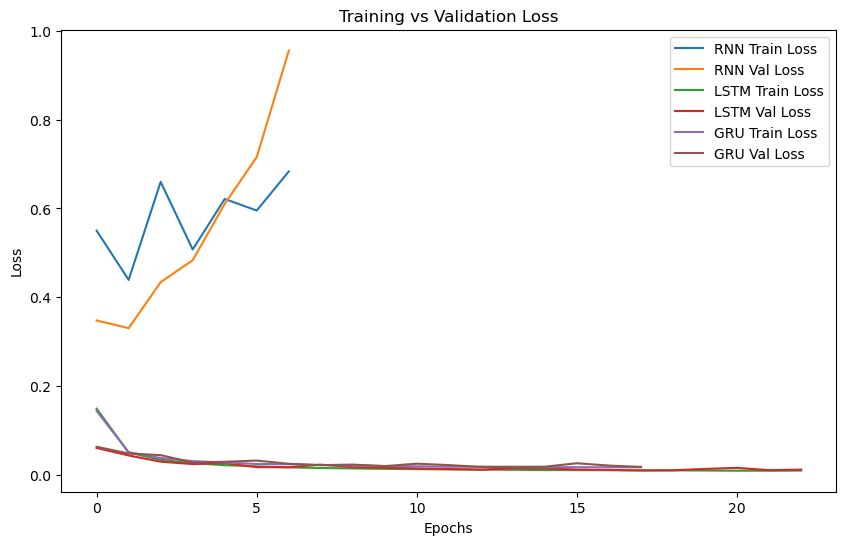

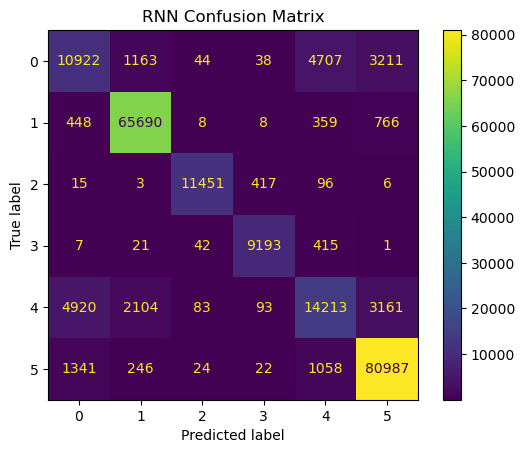

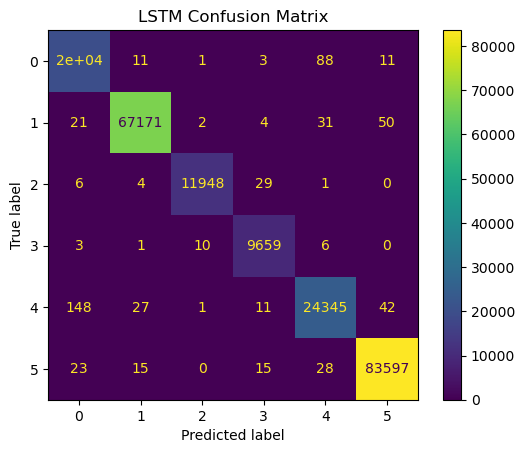

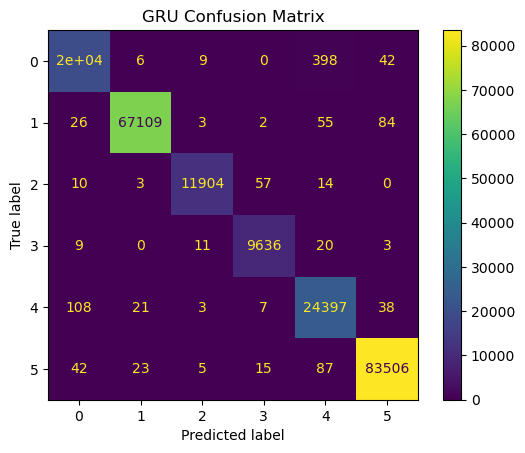

In [10]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Helper function to build models
# -----------------------------
def build_model(model_type, input_shape, num_classes):
    model = Sequential()
    if model_type == "RNN":
        model.add(SimpleRNN(64, input_shape=input_shape))
    elif model_type == "LSTM":
        model.add(LSTM(64, input_shape=input_shape))
    elif model_type == "GRU":
        model.add(GRU(64, input_shape=input_shape))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# Training & Evaluation
# -----------------------------
models = ["RNN", "LSTM", "GRU"]
histories = {}
results = {}

num_classes = len(np.unique(y_train))

for m in models:
    print(f"\nTraining {m} Model...")
    model = build_model(m, X_train.shape[1:], num_classes)
    
    # Early stopping to prevent overfitting
    es = EarlyStopping(patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=64,
        callbacks=[es],
        verbose=1
    )
    
    # Save history
    histories[m] = history
    
    # Predict
    y_pred = np.argmax(model.predict(X_test), axis=1)
    
    # Save results
    results[m] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average="weighted"),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    
    print(f"{m} Accuracy: {results[m]['accuracy']:.4f}")
    print(f"{m} F1-score: {results[m]['f1']:.4f}")

# -----------------------------
# Plot Training vs Validation Loss
# -----------------------------
plt.figure(figsize=(10,6))
for m in models:
    plt.plot(histories[m].history["loss"], label=f"{m} Train Loss")
    plt.plot(histories[m].history["val_loss"], label=f"{m} Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# -----------------------------
# Plot Confusion Matrices
# -----------------------------
for m in models:
    disp = ConfusionMatrixDisplay(results[m]["confusion_matrix"])
    disp.plot()
    plt.title(f"{m} Confusion Matrix")
    plt.show()